# 🔬 Notebook 2 — Model Karşılaştırması: TF-IDF vs Sentence-Transformers

**Proje:** CV – İlan Eşleşmesi (HR Matching)  
**Amaç:** İki farklı vektörleştirme yöntemini karşılaştırmak ve hangisinin daha iyi sonuç verdiğini analiz etmek.

---
| Yöntem | Tür | Avantaj | Dezavantaj |
|---|---|---|---|
| TF-IDF | İstatistiksel | Hızlı, yorumlanabilir | Anlam körü |
| Sentence-Transformers | Derin öğrenme | Anlamsal ilişki kurar | Yavaş, büyük model |

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sample_data import JOB_DESCRIPTION, SAMPLE_CVS
from matching_engine import preprocess_text, MatchingEngine

matplotlib.rcParams['figure.facecolor'] = '#0f1117'
matplotlib.rcParams['axes.facecolor']   = '#1a1f2e'
matplotlib.rcParams['text.color']       = 'white'
matplotlib.rcParams['axes.labelcolor']  = 'white'
matplotlib.rcParams['xtick.color']      = 'white'
matplotlib.rcParams['ytick.color']      = 'white'
matplotlib.rcParams['axes.edgecolor']   = '#2d3561'
plt.style.use('dark_background')

candidates = dict(SAMPLE_CVS)
print('✅ Veriler yüklendi.')

✅ Veriler yüklendi.


## 1. TF-IDF Analizi

In [2]:
print('🔄 TF-IDF hesaplanıyor...')
t0 = time.time()

engine_tfidf = MatchingEngine(use_sentence_transformers=False)
results_tfidf = engine_tfidf.rank_candidates(JOB_DESCRIPTION, candidates, top_n=5)

t1 = time.time()
sure_tfidf = t1 - t0

df_tfidf = pd.DataFrame(results_tfidf)
df_tfidf['yontem'] = 'TF-IDF'
df_tfidf['sure'] = sure_tfidf

print(f'✅ TF-IDF tamamlandı — {sure_tfidf:.3f} saniye')
print()
print(df_tfidf[['rank', 'candidate', 'score']].to_string(index=False))

🔄 TF-IDF hesaplanıyor...
✅ TF-IDF tamamlandı — 0.021 saniye

 rank    candidate    score
    1 Ahmet Yılmaz 0.146800
    2  Zeynep Kaya 0.079470
    3   Mert Demir 0.055651
    4   Can Arslan 0.034900
    5   Elif Şahin 0.020394


## 2. Sentence-Transformers Analizi (opsiyonel)

In [3]:
# NOT: sentence-transformers yüklü değilse TF-IDF'e geri döner
# Yüklemek için: pip install sentence-transformers

try:
    from sentence_transformers import SentenceTransformer
    ST_AVAILABLE = True
    print('✅ sentence-transformers mevcut.')
except ImportError:
    ST_AVAILABLE = False
    print('⚠️  sentence-transformers yüklü değil.')
    print('   Kurmak için: pip install sentence-transformers')
    print('   Bu notebook TF-IDF sonuçlarıyla devam edecek.')

✅ sentence-transformers mevcut.


In [4]:
if ST_AVAILABLE:
    print('🔄 Sentence-Transformers hesaplanıyor (ilk seferde model indirilebilir)...')
    t0 = time.time()

    engine_st = MatchingEngine(use_sentence_transformers=True)
    results_st = engine_st.rank_candidates(JOB_DESCRIPTION, candidates, top_n=5)

    t1 = time.time()
    sure_st = t1 - t0

    df_st = pd.DataFrame(results_st)
    df_st['yontem'] = 'Sentence-Transformers'
    df_st['sure'] = sure_st

    print(f'✅ Sentence-Transformers tamamlandı — {sure_st:.3f} saniye')
    print()
    print(df_st[['rank', 'candidate', 'score']].to_string(index=False))
else:
    df_st = df_tfidf.copy()
    df_st['yontem'] = 'Sentence-Transformers (simüle)'
    print('ℹ️  Simüle mod: TF-IDF sonuçları kullanılıyor.')

🔄 Sentence-Transformers hesaplanıyor (ilk seferde model indirilebilir)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\andya\Documents\BİLGİSAYAR PROGRAMCILIĞI\2º Sınıf\2º Dönem\6. Doğal Dil işleme\Proje\cv_matching\venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\andya\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Sentence-Transformers tamamlandı — 71.822 saniye

 rank    candidate    score
    1 Ahmet Yılmaz 0.737831
    2   Mert Demir 0.730025
    3  Zeynep Kaya 0.615911
    4   Can Arslan 0.519736
    5   Elif Şahin 0.378332


## 3. Karşılaştırmalı Görselleştirme

In [5]:
# Sıralama karşılaştırma tablosu
df_karsi = pd.merge(
    df_tfidf[['candidate', 'score', 'rank']].rename(columns={'score': 'tfidf_skor', 'rank': 'tfidf_sira'}),
    df_st[['candidate', 'score', 'rank']].rename(columns={'score': 'st_skor', 'rank': 'st_sira'}),
    on='candidate'
)
df_karsi['sira_farki'] = df_karsi['tfidf_sira'] - df_karsi['st_sira']
df_karsi['skor_farki'] = (df_karsi['tfidf_skor'] - df_karsi['st_skor']).round(4)

print('Karşılaştırma Tablosu:')
print(df_karsi.to_string(index=False))

Karşılaştırma Tablosu:
   candidate  tfidf_skor  tfidf_sira  st_skor  st_sira  sira_farki  skor_farki
Ahmet Yılmaz    0.146800           1 0.737831        1           0     -0.5910
 Zeynep Kaya    0.079470           2 0.615911        3          -1     -0.5364
  Mert Demir    0.055651           3 0.730025        2           1     -0.6744
  Can Arslan    0.034900           4 0.519736        4           0     -0.4848
  Elif Şahin    0.020394           5 0.378332        5           0     -0.3579


FileNotFoundError: [Errno 2] No such file or directory: 'plots/06_model_karsilastirma.png'

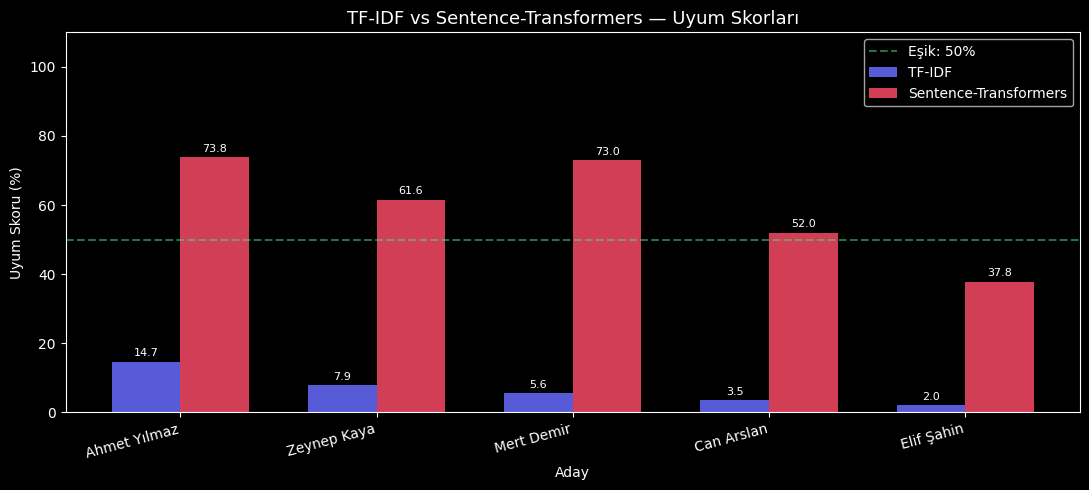

In [6]:
# Yan yana bar grafik
x = np.arange(len(df_karsi))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, df_karsi['tfidf_skor']*100, width,
               label='TF-IDF', color='#6366f1', alpha=0.9)
bars2 = ax.bar(x + width/2, df_karsi['st_skor']*100, width,
               label='Sentence-Transformers', color='#e94560', alpha=0.9)

ax.set_xlabel('Aday')
ax.set_ylabel('Uyum Skoru (%)')
ax.set_title('TF-IDF vs Sentence-Transformers — Uyum Skorları', color='white', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_karsi['candidate'], rotation=15, ha='right')
ax.axhline(y=50, color='#4ade80', linestyle='--', alpha=0.5, label='Eşik: 50%')
ax.legend()
ax.set_ylim(0, 110)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='white')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8, color='white')

plt.tight_layout()
plt.savefig('plots/06_model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. TF-IDF Parametre Optimizasyonu

In [ ]:
# n-gram aralığının etkisini test et
ngram_configs = [(1,1), (1,2), (1,3), (2,2)]
config_labels = ['unigram', 'bi-gram', 'tri-gram', 'sadece-bigram']

all_texts = [preprocess_text(JOB_DESCRIPTION)] + \
            [preprocess_text(cv) for cv in candidates.values()]
names = list(candidates.keys())

resultados_ngram = {}

for (n1, n2), label in zip(ngram_configs, config_labels):
    vec = TfidfVectorizer(ngram_range=(n1, n2), max_features=5000, sublinear_tf=True)
    matrix = vec.fit_transform(all_texts).toarray()
    job_vec = matrix[0]
    cv_vecs = matrix[1:]
    scores = cosine_similarity([job_vec], cv_vecs)[0]
    resultados_ngram[label] = dict(zip(names, scores))

df_ngram = pd.DataFrame(resultados_ngram).T
print('n-gram Konfigürasyonu Karşılaştırması:')
print((df_ngram * 100).round(2).to_string())

In [ ]:
# Heatmap: n-gram vs aday
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df_ngram * 100,
    annot=True, fmt='.1f', cmap='RdPu',
    linewidths=0.5, linecolor='#0f1117',
    ax=ax, cbar_kws={'label': 'Uyum Skoru (%)'}
)
ax.set_title('n-gram Konfigürasyonuna Göre Uyum Skorları (%)', color='white', fontsize=13)
ax.set_xlabel('Aday')
ax.set_ylabel('n-gram Konfigürasyonu')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('plots/07_ngram_optimizasyon.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sonuçlar ve Öneriler

| Kriter | TF-IDF | Sentence-Transformers |
|---|---|---|
| **Hız** | ⚡ Çok hızlı (<0.1s) | 🐌 Yavaş (2-10s, GPU'da hızlanır) |
| **Bellek** | 💚 Düşük | 🔴 Yüksek (~90MB model) |
| **Anlam kavrama** | ❌ Yok | ✅ Var |
| **Dil desteği** | ✅ Çokdil | ✅ Çokdil |
| **Önerilen kullanım** | Hızlı ön eleme | Final sıralama |

**Öneri:** Büyük ölçekli sistemlerde TF-IDF ile ön eleme yapıp, kalan Top-50 adayı Sentence-Transformers ile yeniden sırala.